# Zadanie 1:

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Parametry
dz = 0.01
Q = -1
mu = 1
rho = 1
y1 = -0.4
y2 = 0.4

# Rozmiary siatki
x_min, x_max = -100, 150
y_min, y_max = -40, 40
nx = int((x_max - x_min)) + 1
ny = int((y_max - y_min)) + 1
x = np.linspace(x_min * dz, x_max * dz, nx)
y = np.linspace(y_min * dz, y_max * dz, ny)

psi = np.zeros((nx, ny))
zeta = np.zeros((nx, ny))

# Rozwiązania analityczne do warunków
def psi_func(y):
    return Q / (2 * mu) * (y**3 / 3 - y**2 / 2 * (y1 + y2) + y1 * y2 * y)

def zeta_func(y):
    return Q / (2 * mu) * (2 * y - y1 - y2)

max_iter = 50000
tolerance = 1e-7
check_i = int((0.5/0.01 + 100))   # punkt x = 0.5, czyli punkt i=50 w siatce przesuniętej o +100
check_j = int((0.0/0.01 + 40))    # punkt y = 0, czyli punkt i=0 w siatce przesuniętej o +40


def psi_relax(psi, zeta):
    return (psi[i+1, j] + psi[i-1, j] + psi[i, j+1] + psi[i, j-1] - zeta[i, j] * dz**2) / 4

def zeta_relax(psi, zeta):
    dpsidy = (psi[i, j+1] - psi[i, j-1]) / (2*dz)
    dpsidx = (psi[i+1, j] - psi[i-1, j]) / (2*dz)
    dzetadx = (zeta[i+1, j] - zeta[i-1, j]) / (2*dz)
    dzetady = (zeta[i, j+1] - zeta[i, j-1]) / (2*dz)
    return (zeta[i+1, j] + zeta[i-1, j] + zeta[i, j+1] + zeta[i, j-1]) / 4 - (dpsidy * dzetadx - dpsidx * dzetady) * dz**2 / 4


In [87]:
# Warunki brzegowe na całym obwodzie z analitycznych funkcji
for i in range(nx):
    psi[i, 0] = psi_func(y[0])
    psi[i, -1] = psi_func(y[-1])
    zeta[i, 0] = zeta_func(y[0])
    zeta[i, -1] = zeta_func(y[-1])

for j in range(ny):
    psi[0, j] = psi_func(y[j])
    psi[-1, j] = psi_func(y[j])
    zeta[0, j] = zeta_func(y[j])
    zeta[-1, j] = zeta_func(y[j])

In [88]:
for it in range(3000):
    psi_old = psi.copy()
    zeta_old = zeta.copy()

    # Aktualizacja psi
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            psi[i, j] = psi_relax(psi, zeta)

    # Aktualizacja zeta
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            zeta[i, j] = zeta_relax(psi, zeta)

    # Sprawdzenie zbieżności, ale dopiero po pierwszych 100 iteracjach
    if it >= 100:
        d_psi = abs(psi[check_i, check_j] - psi_old[check_i, check_j])
        d_zeta = abs(zeta[check_i, check_j] - zeta_old[check_i, check_j])
        if max(d_psi, d_zeta) < tolerance:
            print(f"Zbieżność osiągnięta po {it} iteracjach.")
            break



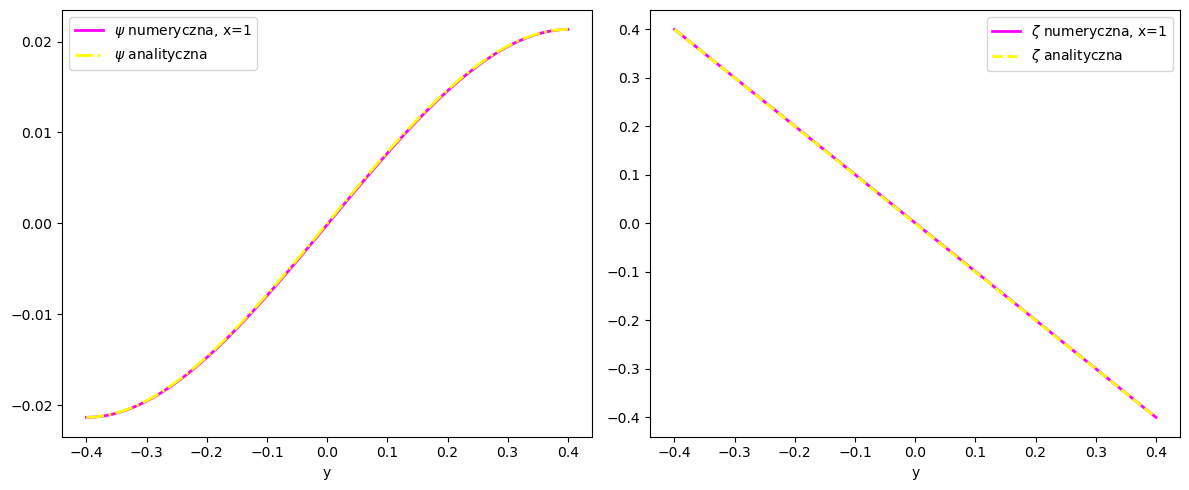

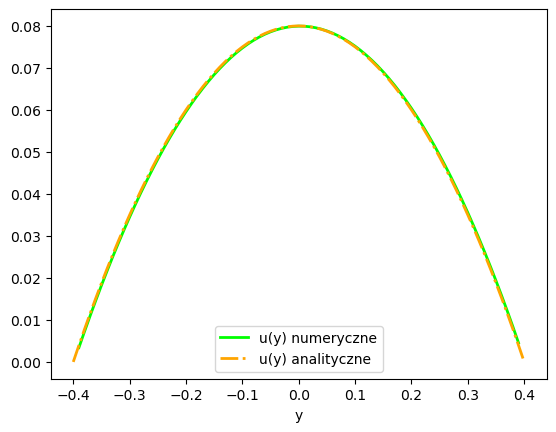

In [89]:
x0_index = int((0.0/0.01 + 100))     # x = 0
x1_index = int((0.7/0.01 + 100))     # x = 0.7

plt.figure(figsize=(12, 5))
# przekrój x = 0
plt.subplot(1, 2, 1)
plt.plot(y, psi[x1_index, :], label=r'$\psi$ numeryczna, x=1', color='fuchsia', linewidth=2)
plt.plot(y, psi_func(y), '-.', label=r'$\psi$ analityczna', color='yellow', linewidth=2)
#plt.title('Funkcja strumienia (x = 0)')
plt.xlabel('y')
plt.legend()

# przekrój x = 0.7
plt.subplot(1, 2, 2)
plt.plot(y, zeta[x1_index, :], label=r'$\zeta$ numeryczna, x=1',color='fuchsia', linewidth=2)
plt.plot(y, zeta_func(y), '--', label=r'$\zeta$ analityczna',color='yellow', linewidth=2)

#plt.title('Wirowość (x = 0)')
plt.xlabel('y')
plt.legend()

plt.tight_layout()
plt.show()

# prędkość u numerycznie 
def u_func_num(psi, dz):
    nx, ny = psi.shape
    u = np.zeros((nx, ny-2))
    
    for i in range(nx):
        for j in range(1, ny-1):  # omijamy brzegi, bo nie policzymy pochodnej z nich
            u[i, j-1] = (psi[i, j+1] - psi[i, j-1]) / (2 * dz)
    return u

# prędkość u analitycznie (pochodna dpsi/dy)
def u_func(y):
    return Q / (2*mu)*(y**2 - y*y1 - y*y2 + y1*y2)


u = u_func_num(psi, dz)
u_x0 = u[x0_index, :]

plt.plot(y[1:-1], u_x0, label='u(y) numeryczne',color='lime', linewidth=2) # y bez brzegów znów
plt.plot(y, u_func(y), '-.', label='u(y) analityczne',color='orange', linewidth=2)
#plt.title('Prędkość pozioma u(y) w x = 0')
plt.xlabel('y')
plt.legend()
plt.show()

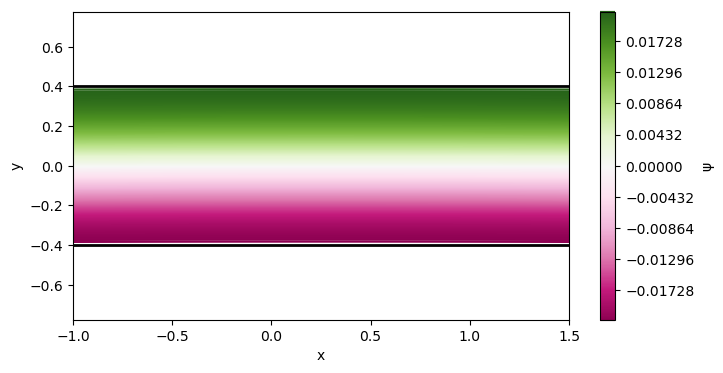

In [90]:
plt.figure(figsize=(8, 4))
X, Y = np.meshgrid(x, y, indexing='ij')
plt.contour(X, Y, psi, levels=700, cmap='PiYG')
plt.plot([-1, 1.5], [-0.4, -0.4], 'black', lw=2)  # dół
plt.plot([-1, 1.5], [0.4, 0.4], 'black', lw=2)  # góra
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='ψ')
plt.axis('equal')
plt.show()

# Zadanie 2: Rozwiązanie na pętlach, nie optymalny czas wykonania. Jeszcze niżej rozwiązanie używając tablic numpy.

In [17]:
# wymiary zastawki
ik = 5
jk = 10

i_left = nx - x_max - ik
i_right   = nx - x_max + ik
j_top = jk - y_min
j_bot = 0

x0 = x[i_left]
x1 = x[i_right]
y0 = y[j_bot]
y1 = y[j_top]

for it in range(max_iter):
    psi_old = psi.copy()
    zeta_old = zeta.copy()

    # góra i dół rury A i B
    for i in range(nx):
        psi[i, 0] = psi_func(y1)
        psi[i, -1] = psi_func(y[-1])

    # boki rury
    for j in range(ny):
        psi[0, j] = psi_func(y[j])
        psi[-1, j] = psi_func(y[j])

    # góra przeszkody E
    for i in range(i_left + 1, i_right - 1):
        psi[i, j_top] = psi_func(y1)

    # boki przeszkody C i D
    for j in range(1, j_top):
        psi[i_left, j] = psi_func(y1)
        psi[i_right, j] = psi_func(y1)
    
    # góra rury:
    for i in range(nx):
        zeta[i, ny-1] = 2 * (psi[i, ny-2] - psi[i, ny-1]) / dz**2

    # dół rury A i B
    for i in range(1, i_left+1):
        zeta[i, 0] = 2 * (psi[i, 1] - psi[i, 0]) / dz**2
    for i in range(i_right, nx - 1):
        zeta[i, 0] = 2 * (psi[i, 1] - psi[i, 0]) / dz**2

    # boki przeszkody C i D
    for j in range(1, j_top):
        zeta[i_left, j] = 2 * (psi[i_left - 1, j] - psi[i_left, j]) / dz**2
        zeta[i_right, j] = 2 * (psi[i_right + 1, j] - psi[i_right, j]) / dz**2

    # góra przeszkody E
    for i in range(i_left + 1, i_right - 1):
        zeta[i, j_top] = 2 * (psi[i, j_top + 1] - psi[i, j_top]) / dz**2

    # rogi (średnia arytmetyczna warunków)
    zeta[i_left, j_top] = 0.5 * (
        2 * (psi[i_left - 1, j_top] - psi[i_left, j_top]) / dz**2 +
        2 * (psi[i_left, j_top + 1] - psi[i_left, j_top]) / dz**2
    )

    zeta[i_right, j_top] = 0.5 * (
        2 * (psi[i_right + 1, j_top] - psi[i_right, j_top]) / dz**2 +
        2 * (psi[i_right, j_top + 1] - psi[i_right, j_top]) / dz**2
    )
    
    if it % 100 == 0:
        print(f"iter={it}: psi(50,0)={psi[150, 40]:.5f}, psi(60,20)={psi[160, 60]:.5f}")
    
    # Aktualizacja psi
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            psi[i, j] = psi_relax(psi, zeta)

    # Aktualizacja zeta
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            zeta[i, j] = zeta_relax(psi, zeta)
        
    # Sprawdzenie zbieżności
    if it >= 100:
        d_psi = abs(psi[check_i, check_j] - psi_old[check_i, check_j])
        d_zeta = abs(zeta[check_i, check_j] - zeta_old[check_i, check_j])
        if max(d_psi, d_zeta) < tolerance:
            print(f"Zbieżność osiągnięta po {it} iteracjach.")
            break


iter=0: psi(50,0)=0.00000, psi(60,20)=0.00000
iter=100: psi(50,0)=-0.00000, psi(60,20)=0.00028
iter=200: psi(50,0)=-0.00004, psi(60,20)=0.00072
iter=300: psi(50,0)=-0.00006, psi(60,20)=0.00092
iter=400: psi(50,0)=-0.00006, psi(60,20)=0.00099
iter=500: psi(50,0)=-0.00006, psi(60,20)=0.00101
iter=600: psi(50,0)=-0.00005, psi(60,20)=0.00100
iter=700: psi(50,0)=-0.00005, psi(60,20)=0.00098
iter=800: psi(50,0)=-0.00004, psi(60,20)=0.00096
iter=900: psi(50,0)=-0.00003, psi(60,20)=0.00094
Zbieżność osiągnięta po 947 iteracjach.


# Zadanie 2: Rozwiązanie tablicami NumPy.

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

dz = 0.01
Q = -600
mu = 1
rho = 1
y1 = -0.4
y2 = 0.4
tolerance = 1e-7

x_min, x_max = -100, 150
y_min, y_max = -40, 40
nx = int((x_max - x_min)) + 1
ny = int((y_max - y_min)) + 1
x = np.linspace(x_min * dz, x_max * dz, nx)
y = np.linspace(y_min * dz, y_max * dz, ny)
X, Y = np.meshgrid(x, y, indexing='ij')

psi = np.zeros((nx, ny))
zeta = np.zeros((nx, ny))

def psi_func(y):
    return Q / (2 * mu) * (y**3 / 3 - y**2 / 2 * (y1 + y2) + y1 * y2 * y)

def zeta_func(y):
    return Q / (2 * mu) * (2 * y - y1 - y2)

check_i = int((0.5/0.01 + 100))  # punkt x = 0.5
check_j = int((0.0/0.01 + 40))   # punkt y = 0

# wymiary zastawki
ik = 5
jk = 10

i_left = nx - x_max - ik
i_right = nx - x_max + ik
j_top = jk - y_min
j_bot = 0

In [67]:
for it in range(max_iter):
    psi_old = psi.copy()
    zeta_old = zeta.copy()

    # góra i dół rury
    psi[:, 0] = psi_func(y1)
    psi[:, -1] = psi_func(y[-1])
    # boki rury
    psi[0, :] = psi_func(y)
    psi[-1, :] = psi_func(y)
    # boki przeszkody
    psi[i_left+1:i_right-1, j_top] = psi_func(y1)
    psi[i_left, 1:j_top] = psi_func(y1)
    psi[i_right, 1:j_top] = psi_func(y1)

    zeta[:, -1] = 2 * (psi[:, -2] - psi[:, -1]) / dz**2
    zeta[:i_left+1, 0] = 2 * (psi[:i_left+1, 1] - psi[:i_left+1, 0]) / dz**2
    zeta[i_right:, 0] = 2 * (psi[i_right:, 1] - psi[i_right:, 0]) / dz**2
    zeta[i_left, 1:j_top] = 2 * (psi[i_left-1, 1:j_top] - psi[i_left, 1:j_top]) / dz**2
    zeta[i_right, 1:j_top] = 2 * (psi[i_right+1, 1:j_top] - psi[i_right, 1:j_top]) / dz**2
    zeta[i_left+1:i_right-1, j_top] = 2 * (psi[i_left+1:i_right-1, j_top+1] - psi[i_left+1:i_right-1, j_top]) / dz**2

    # rogi przeszkody
    zeta[i_left, j_top] = 0.5 * (
        2 * (psi[i_left - 1, j_top] - psi[i_left, j_top]) / dz**2 +
        2 * (psi[i_left, j_top + 1] - psi[i_left, j_top]) / dz**2
    )
    zeta[i_right, j_top] = 0.5 * (
        2 * (psi[i_right + 1, j_top] - psi[i_right, j_top]) / dz**2 +
        2 * (psi[i_right, j_top + 1] - psi[i_right, j_top]) / dz**2
    )

    if it % 500 == 0:
        print(f"iter={it}: psi(50,0)={psi[150, 40]:.5f}, psi(60,20)={psi[160, 60]:.5f}")

    # psi relaksacja
    psi[1:-1, 1:-1] = 0.25 * (
        psi[2:, 1:-1] + psi[:-2, 1:-1] + psi[1:-1, 2:] + psi[1:-1, :-2] - zeta[1:-1, 1:-1] * dz**2
    )

    # zeta relaksacja
    dpsidy = (psi[1:-1, 2:] - psi[1:-1, :-2]) / (2*dz)
    dpsidx = (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2*dz)
    dzetadx = (zeta[2:, 1:-1] - zeta[:-2, 1:-1]) / (2*dz)
    dzetady = (zeta[1:-1, 2:] - zeta[1:-1, :-2]) / (2*dz)

    zeta[1:-1, 1:-1] = 0.25 * (
        zeta[2:, 1:-1] + zeta[:-2, 1:-1] + zeta[1:-1, 2:] + zeta[1:-1, :-2]
    ) - 0.25 * (dpsidy * dzetadx - dpsidx * dzetady) * dz**2

    # Sprawdzenie zbieżności
    if it >= 1000:
        d_psi = abs(psi[check_i, check_j] - psi_old[check_i, check_j])
        d_zeta = abs(zeta[check_i, check_j] - zeta_old[check_i, check_j])
        if max(d_psi, d_zeta) < tolerance:
            print(f"Zbieżność osiągnięta po {it} iteracjach.")
            break


iter=0: psi(50,0)=0.00000, psi(60,20)=0.00000
iter=500: psi(50,0)=-0.66380, psi(60,20)=7.93332
iter=1000: psi(50,0)=-5.34689, psi(60,20)=8.61014
iter=1500: psi(50,0)=-9.38411, psi(60,20)=7.16895
iter=2000: psi(50,0)=-11.50136, psi(60,20)=5.50554
iter=2500: psi(50,0)=-12.49212, psi(60,20)=4.18562
iter=3000: psi(50,0)=-12.97506, psi(60,20)=3.29508
iter=3500: psi(50,0)=-13.24014, psi(60,20)=2.74420
iter=4000: psi(50,0)=-13.39427, psi(60,20)=2.42207
iter=4500: psi(50,0)=-13.47892, psi(60,20)=2.24518
iter=5000: psi(50,0)=-13.51828, psi(60,20)=2.15867
iter=5500: psi(50,0)=-13.53064, psi(60,20)=2.12713
iter=6000: psi(50,0)=-13.52905, psi(60,20)=2.12741
iter=6500: psi(50,0)=-13.52133, psi(60,20)=2.14436
iter=7000: psi(50,0)=-13.51142, psi(60,20)=2.16843
iter=7500: psi(50,0)=-13.50114, psi(60,20)=2.19399
iter=8000: psi(50,0)=-13.49136, psi(60,20)=2.21805
iter=8500: psi(50,0)=-13.48257, psi(60,20)=2.23921
iter=9000: psi(50,0)=-13.47506, psi(60,20)=2.25702
iter=9500: psi(50,0)=-13.46890, psi(60,2

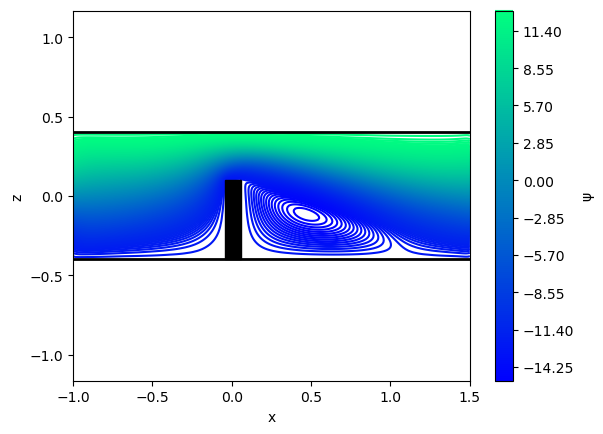

In [68]:
x0 = x[i_left]
x1 = x[i_right]
y0 = y[j_bot]
y1 = y[j_top]

X, Y = np.meshgrid(x, y, indexing='ij')

plt.contour(X, Y, psi, levels=200, cmap='winter')
plt.xlabel('x')
plt.ylabel('z')
plt.colorbar(label='ψ')
plt.axis('equal')

# elementy (krawędzie rury + przeszkoda)
plt.plot([-1, 1.5], [-0.4, -0.4], 'black', lw=2)  # dół
plt.plot([-1, 1.5], [0.4, 0.4], 'black', lw=2)  # góra
rect = patches.Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=1,
    edgecolor='black',
    facecolor='black',
    alpha=1,
    zorder=10
)
plt.gca().add_patch(rect)

plt.show()

# Zadanie 3:

In [76]:
A = 1
Q = 0
y1 = -0.4
psi = np.zeros((nx, ny))
zeta = np.zeros((nx, ny))

def psi_func(y):
    return A*y

def zeta_func(y):
    return 0

for it in range(max_iter):
    
    psi_old = psi.copy()
    zeta_old = zeta.copy()
    
    psi[:, 0] = psi_func(y1)
    psi[:, -1] = psi_func(y[-1])
    psi[0, :] = psi_func(y)
    psi[-1, :] = psi_func(y)
    psi[i_left+1:i_right-1, j_top] = psi_func(y1)
    psi[i_left, 1:j_top] = psi_func(y1)
    psi[i_right, 1:j_top] = psi_func(y1)
    
    if it % 500 == 0:
        print(f"iter={it}: psi(50,0)={psi[150, 40]:.5f}, psi(60,20)={psi[160, 60]:.5f}")

    # Aktualizacja psi (relaksacja)
    psi[1:-1, 1:-1] = 0.25 * (
        psi[2:, 1:-1] + psi[:-2, 1:-1] + psi[1:-1, 2:] + psi[1:-1, :-2] - zeta[1:-1, 1:-1] * dz**2
    )

    # Aktualizacja zeta (relaksacja)
    dpsidy = (psi[1:-1, 2:] - psi[1:-1, :-2]) / (2*dz)
    dpsidx = (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2*dz)
    dzetadx = (zeta[2:, 1:-1] - zeta[:-2, 1:-1]) / (2*dz)
    dzetady = (zeta[1:-1, 2:] - zeta[1:-1, :-2]) / (2*dz)

    zeta[1:-1, 1:-1] = 0.25 * (
        zeta[2:, 1:-1] + zeta[:-2, 1:-1] + zeta[1:-1, 2:] + zeta[1:-1, :-2]
    ) - 0.25 * (dpsidy * dzetadx - dpsidx * dzetady) * dz**2

    # Sprawdzenie zbieżności
    if it >= 1000:
        d_psi = abs(psi[check_i, check_j] - psi_old[check_i, check_j])
        d_zeta = abs(zeta[check_i, check_j] - zeta_old[check_i, check_j])
        if max(d_psi, d_zeta) < tolerance:
            print(f"Zbieżność osiągnięta po {it} iteracjach.")
            break
      

iter=0: psi(50,0)=0.00000, psi(60,20)=0.00000
iter=500: psi(50,0)=-0.00172, psi(60,20)=0.08231
iter=1000: psi(50,0)=-0.01399, psi(60,20)=0.14317
iter=1500: psi(50,0)=-0.02764, psi(60,20)=0.16730
iter=2000: psi(50,0)=-0.03816, psi(60,20)=0.17539
iter=2500: psi(50,0)=-0.04572, psi(60,20)=0.17705
iter=3000: psi(50,0)=-0.05109, psi(60,20)=0.17639
iter=3500: psi(50,0)=-0.05494, psi(60,20)=0.17506
iter=4000: psi(50,0)=-0.05772, psi(60,20)=0.17370
iter=4500: psi(50,0)=-0.05975, psi(60,20)=0.17252
iter=5000: psi(50,0)=-0.06124, psi(60,20)=0.17157
iter=5500: psi(50,0)=-0.06235, psi(60,20)=0.17082
iter=6000: psi(50,0)=-0.06317, psi(60,20)=0.17023
iter=6500: psi(50,0)=-0.06379, psi(60,20)=0.16978
iter=7000: psi(50,0)=-0.06426, psi(60,20)=0.16944
iter=7500: psi(50,0)=-0.06461, psi(60,20)=0.16917
iter=8000: psi(50,0)=-0.06488, psi(60,20)=0.16897
iter=8500: psi(50,0)=-0.06509, psi(60,20)=0.16881
iter=9000: psi(50,0)=-0.06525, psi(60,20)=0.16869
iter=9500: psi(50,0)=-0.06537, psi(60,20)=0.16860
iter=

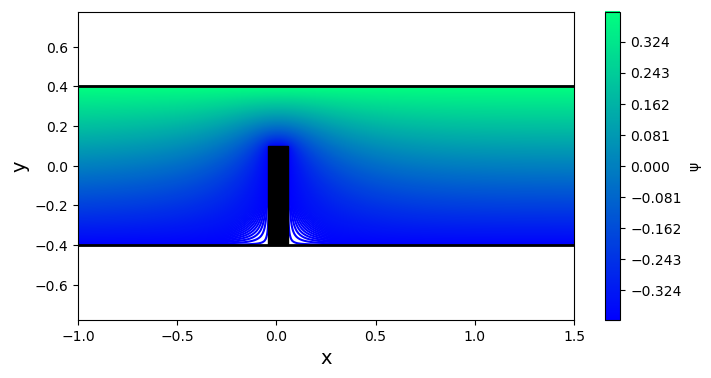

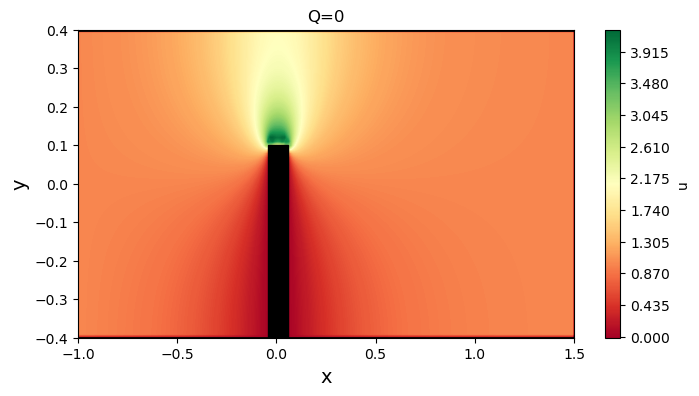

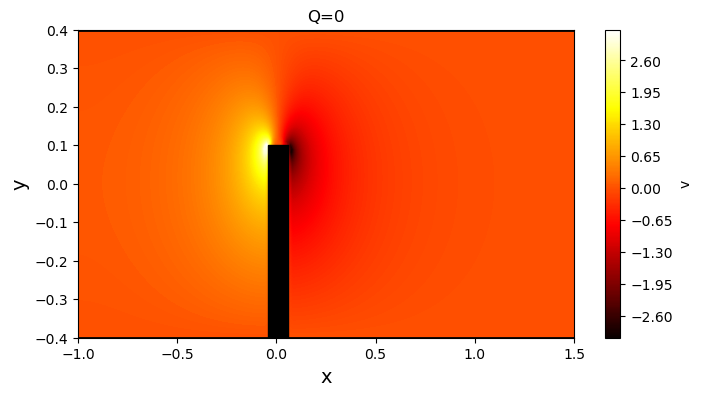

In [81]:
x0 = x[i_left]
x1 = x[i_right]
y0 = y[j_bot]
y1 = y[j_top]

X, Y = np.meshgrid(x, y, indexing='ij')
plt.figure(figsize=(8, 4))
plt.contour(X, Y, psi, levels=300, cmap='winter')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.colorbar(label='ψ')
plt.axis('equal')

# elementy (krawędzie rury + przeszkoda)
plt.plot([-1, 1.5], [-0.4, -0.4], 'black', lw=2)  # dół
plt.plot([-1, 1.5], [0.4, 0.4], 'black', lw=2)  # góra
rect = patches.Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=1,
    edgecolor='black',
    facecolor='black',
    alpha=1,
    zorder=10
)
plt.gca().add_patch(rect)

# Obliczenie prędkości u i v
u = np.zeros_like(psi)
v = np.zeros_like(psi)

u[1:-1, 1:-1] = (psi[1:-1, 2:] - psi[1:-1, :-2]) / (2 * dz)
v[1:-1, 1:-1] = -(psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2 * dz)
    
plt.figure(figsize=(8, 4))
plt.contourf(X, Y, u, levels=300, cmap='RdYlGn')
plt.title(f"Q={Q}")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.colorbar(label='u')
plt.plot([-1, 1.5], [-0.4, -0.4], 'black', lw=2)  # dół
plt.plot([-1, 1.5], [0.4, 0.4], 'black', lw=2)  # góra
plt.gca().add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, color='black', zorder=10))
    
plt.figure(figsize=(8, 4))
plt.contourf(X, Y, v, levels=300, cmap='hot')
plt.title(f"Q={Q}")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.colorbar(label='v')
plt.plot([-1, 1.5], [-0.4, -0.4], 'black', lw=2)  # dół
plt.plot([-1, 1.5], [0.4, 0.4], 'black', lw=2)  # góra
plt.gca().add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, color='black', zorder=10))
    
plt.show()

# Ponownie zadanie 2 -> wszystkie Q

iter=0: psi(50,0)=0.00000, psi(60,20)=0.00000
iter=500: psi(50,0)=-0.00084, psi(60,20)=0.01357
iter=1000: psi(50,0)=-0.00396, psi(60,20)=0.01564
iter=1500: psi(50,0)=-0.00556, psi(60,20)=0.01402
iter=2000: psi(50,0)=-0.00591, psi(60,20)=0.01294
iter=2500: psi(50,0)=-0.00573, psi(60,20)=0.01270
iter=3000: psi(50,0)=-0.00541, psi(60,20)=0.01282
iter=3500: psi(50,0)=-0.00510, psi(60,20)=0.01300
iter=4000: psi(50,0)=-0.00486, psi(60,20)=0.01315
iter=4500: psi(50,0)=-0.00470, psi(60,20)=0.01324
Zbieżność osiągnięta po 4784 iteracjach.


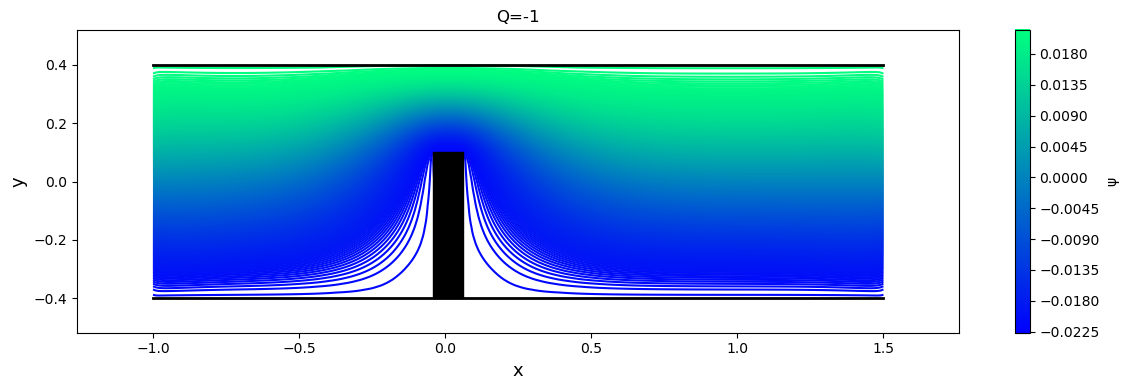

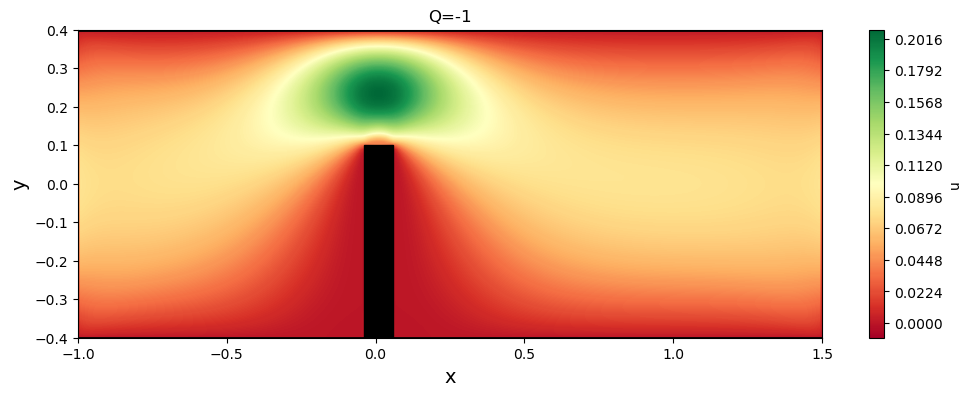

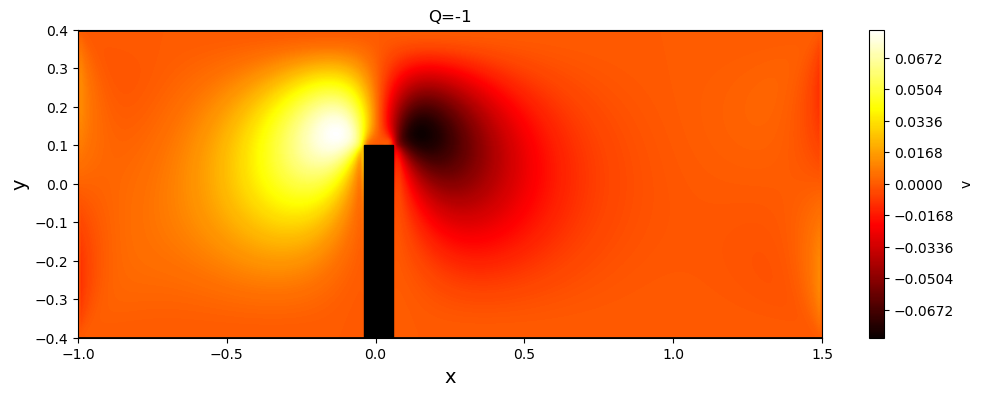

iter=0: psi(50,0)=0.00000, psi(60,20)=0.00000
iter=500: psi(50,0)=-0.00843, psi(60,20)=0.13574
iter=1000: psi(50,0)=-0.03989, psi(60,20)=0.15632
iter=1500: psi(50,0)=-0.05632, psi(60,20)=0.13998
iter=2000: psi(50,0)=-0.06018, psi(60,20)=0.12910
iter=2500: psi(50,0)=-0.05854, psi(60,20)=0.12665
iter=3000: psi(50,0)=-0.05530, psi(60,20)=0.12788
iter=3500: psi(50,0)=-0.05218, psi(60,20)=0.12976
iter=4000: psi(50,0)=-0.04977, psi(60,20)=0.13127
iter=4500: psi(50,0)=-0.04816, psi(60,20)=0.13225
iter=5000: psi(50,0)=-0.04723, psi(60,20)=0.13281
iter=5500: psi(50,0)=-0.04680, psi(60,20)=0.13307
iter=6000: psi(50,0)=-0.04668, psi(60,20)=0.13314
iter=6500: psi(50,0)=-0.04673, psi(60,20)=0.13311
iter=7000: psi(50,0)=-0.04686, psi(60,20)=0.13303
iter=7500: psi(50,0)=-0.04701, psi(60,20)=0.13294
iter=8000: psi(50,0)=-0.04713, psi(60,20)=0.13286
iter=8500: psi(50,0)=-0.04723, psi(60,20)=0.13280
Zbieżność osiągnięta po 8858 iteracjach.


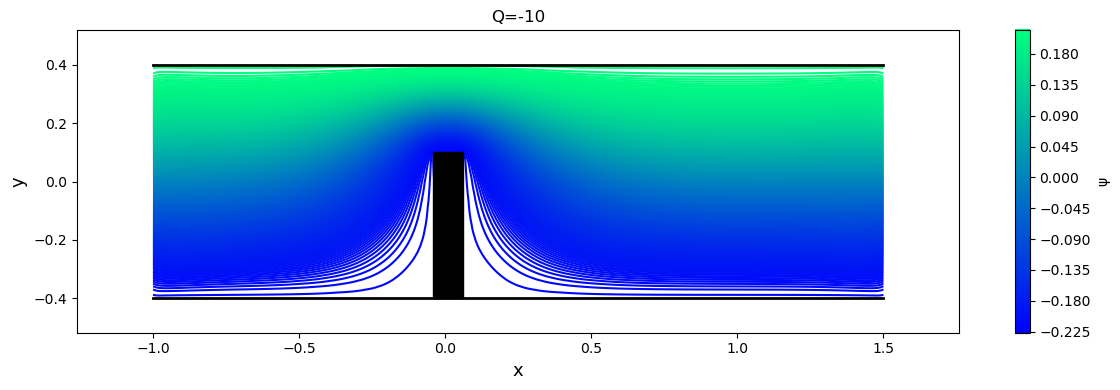

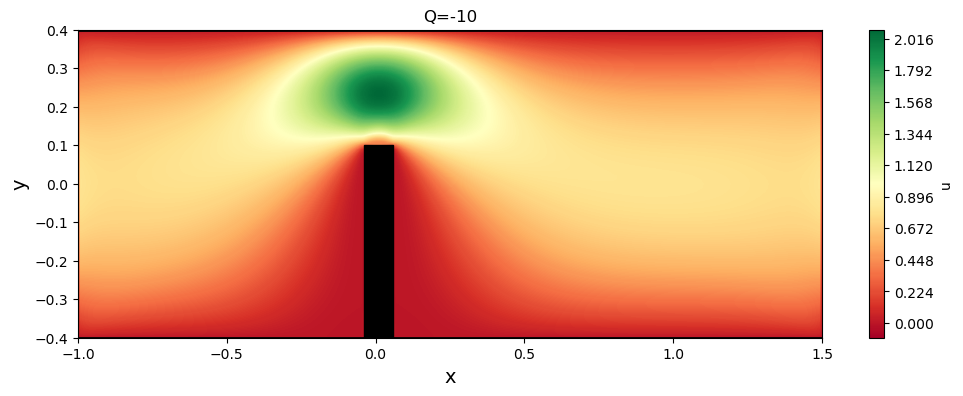

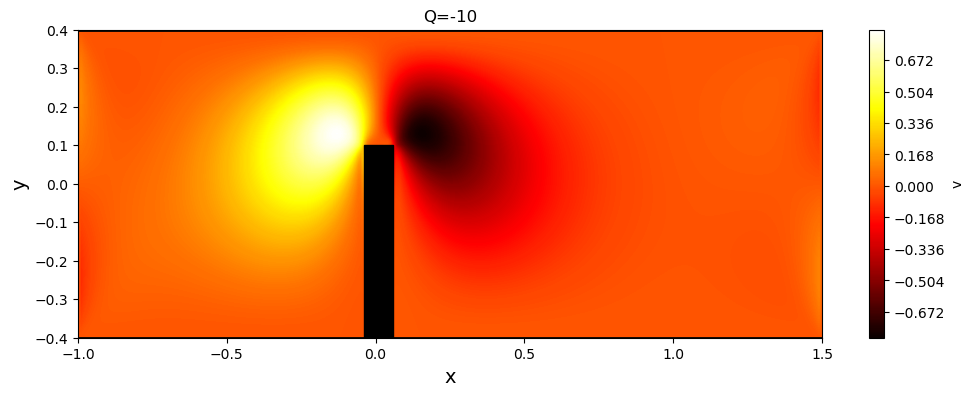

iter=0: psi(50,0)=0.00000, psi(60,20)=0.00000
iter=500: psi(50,0)=-0.08644, psi(60,20)=1.35644
iter=1000: psi(50,0)=-0.44076, psi(60,20)=1.54459
iter=1500: psi(50,0)=-0.67569, psi(60,20)=1.36032
iter=2000: psi(50,0)=-0.76193, psi(60,20)=1.24204
iter=2500: psi(50,0)=-0.76988, psi(60,20)=1.21220
iter=3000: psi(50,0)=-0.74853, psi(60,20)=1.22066
iter=3500: psi(50,0)=-0.72101, psi(60,20)=1.23808
iter=4000: psi(50,0)=-0.69674, psi(60,20)=1.25392
iter=4500: psi(50,0)=-0.67864, psi(60,20)=1.26567
iter=5000: psi(50,0)=-0.66670, psi(60,20)=1.27340
iter=5500: psi(50,0)=-0.65975, psi(60,20)=1.27790
iter=6000: psi(50,0)=-0.65634, psi(60,20)=1.28009
iter=6500: psi(50,0)=-0.65519, psi(60,20)=1.28079
iter=7000: psi(50,0)=-0.65532, psi(60,20)=1.28065
iter=7500: psi(50,0)=-0.65603, psi(60,20)=1.28012
iter=8000: psi(50,0)=-0.65690, psi(60,20)=1.27949
iter=8500: psi(50,0)=-0.65770, psi(60,20)=1.27892
iter=9000: psi(50,0)=-0.65833, psi(60,20)=1.27848
iter=9500: psi(50,0)=-0.65876, psi(60,20)=1.27818
iter=

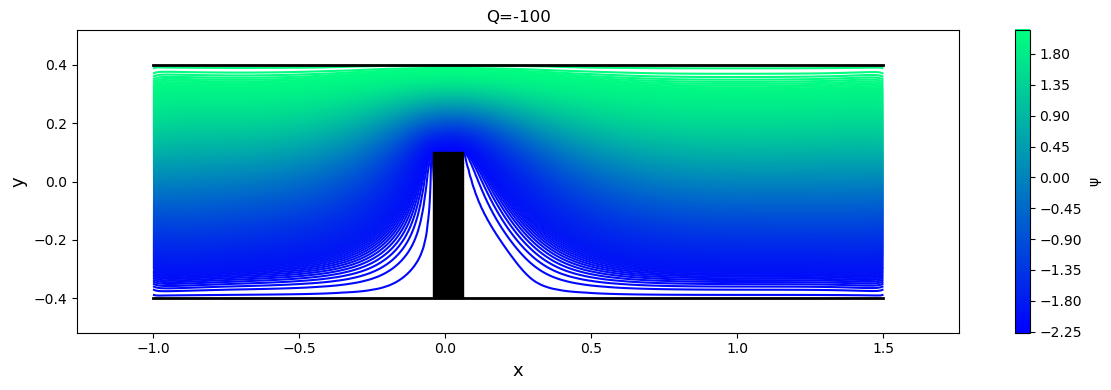

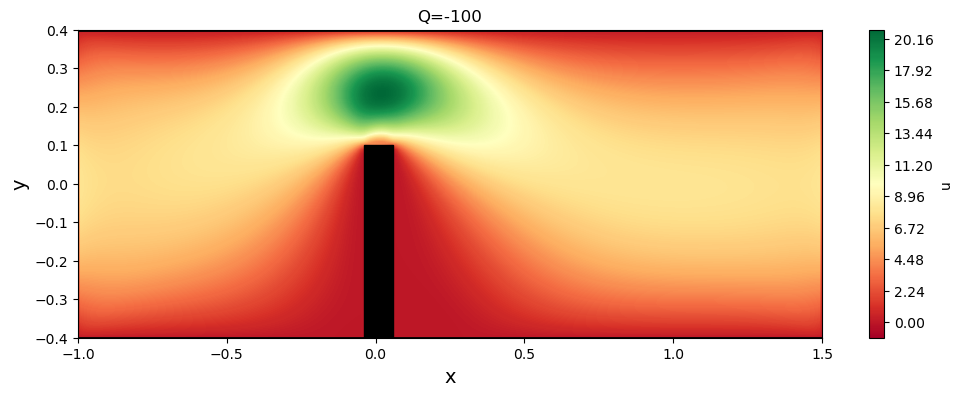

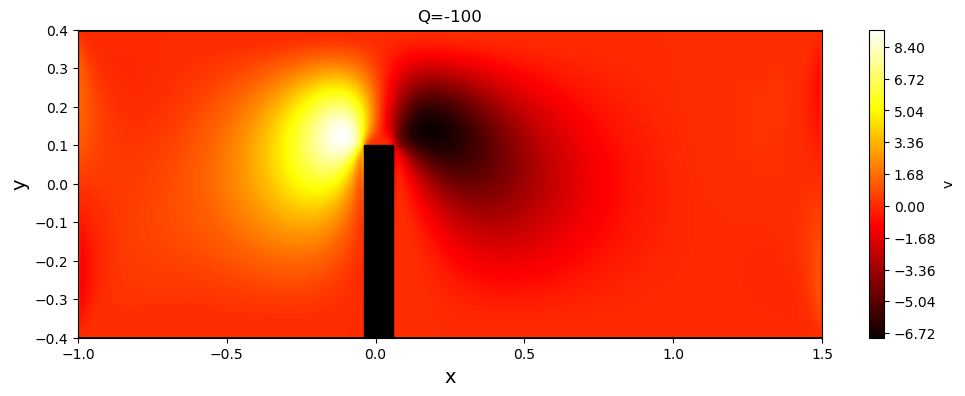

iter=0: psi(50,0)=0.00000, psi(60,20)=0.00000
iter=500: psi(50,0)=-0.17942, psi(60,20)=2.70894
iter=1000: psi(50,0)=-1.04396, psi(60,20)=3.02107
iter=1500: psi(50,0)=-1.73294, psi(60,20)=2.59560
iter=2000: psi(50,0)=-2.04221, psi(60,20)=2.32599
iter=2500: psi(50,0)=-2.14416, psi(60,20)=2.22730
iter=3000: psi(50,0)=-2.15717, psi(60,20)=2.20856
iter=3500: psi(50,0)=-2.13574, psi(60,20)=2.22122
iter=4000: psi(50,0)=-2.10419, psi(60,20)=2.24375
iter=4500: psi(50,0)=-2.07354, psi(60,20)=2.26649
iter=5000: psi(50,0)=-2.04824, psi(60,20)=2.28554
iter=5500: psi(50,0)=-2.02930, psi(60,20)=2.29989
iter=6000: psi(50,0)=-2.01614, psi(60,20)=2.30985
iter=6500: psi(50,0)=-2.00761, psi(60,20)=2.31623
iter=7000: psi(50,0)=-2.00252, psi(60,20)=2.31996
iter=7500: psi(50,0)=-1.99982, psi(60,20)=2.32185
iter=8000: psi(50,0)=-1.99868, psi(60,20)=2.32257
iter=8500: psi(50,0)=-1.99846, psi(60,20)=2.32261
iter=9000: psi(50,0)=-1.99874, psi(60,20)=2.32231
iter=9500: psi(50,0)=-1.99922, psi(60,20)=2.32189
iter=

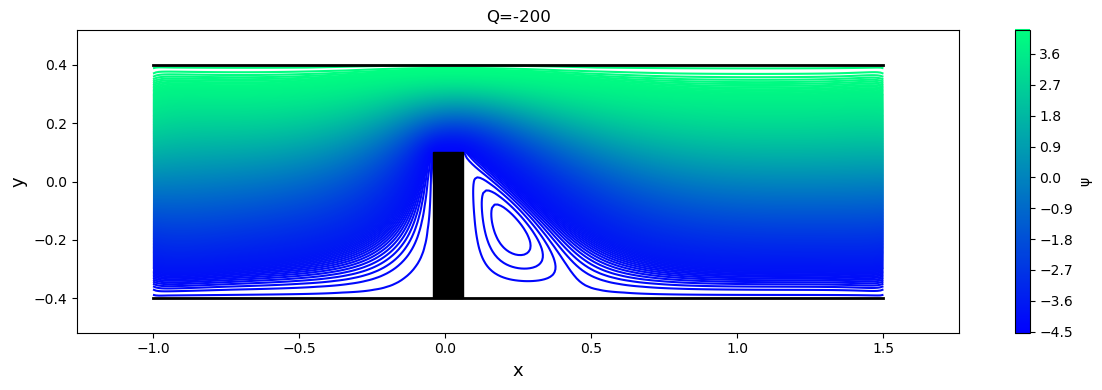

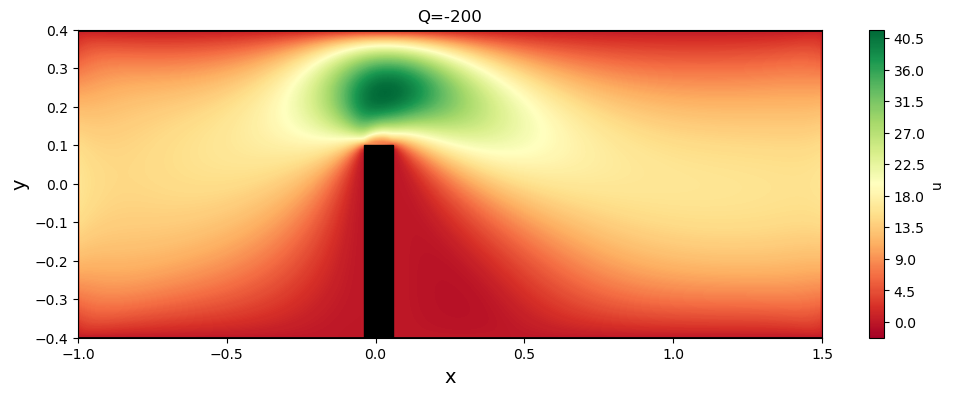

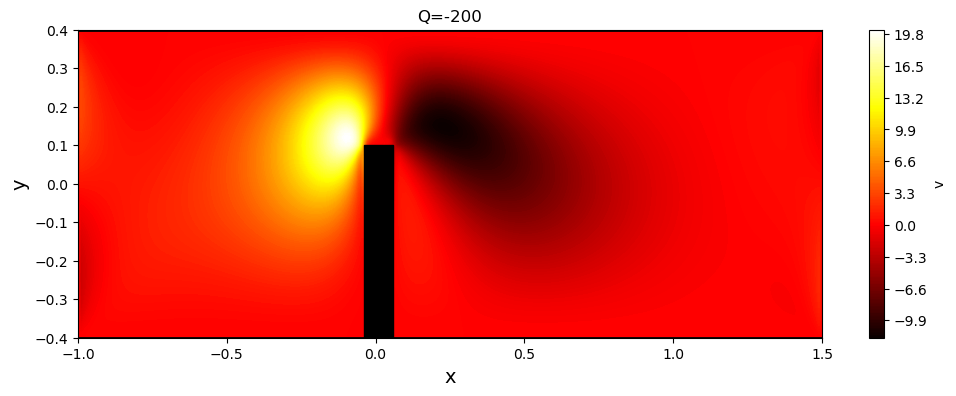

iter=0: psi(50,0)=0.00000, psi(60,20)=0.00000
iter=500: psi(50,0)=-0.39640, psi(60,20)=5.37476
iter=1000: psi(50,0)=-2.90254, psi(60,20)=5.78236
iter=1500: psi(50,0)=-5.06168, psi(60,20)=4.85644
iter=2000: psi(50,0)=-6.21413, psi(60,20)=4.07059
iter=2500: psi(50,0)=-6.77700, psi(60,20)=3.54625
iter=3000: psi(50,0)=-7.04141, psi(60,20)=3.24012
iter=3500: psi(50,0)=-7.15915, psi(60,20)=3.08530
iter=4000: psi(50,0)=-7.20413, psi(60,20)=3.02193
iter=4500: psi(50,0)=-7.21234, psi(60,20)=3.00892
iter=5000: psi(50,0)=-7.20228, psi(60,20)=3.02133
iter=5500: psi(50,0)=-7.18412, psi(60,20)=3.04475
iter=6000: psi(50,0)=-7.16358, psi(60,20)=3.07111
iter=6500: psi(50,0)=-7.14384, psi(60,20)=3.09616
iter=7000: psi(50,0)=-7.12650, psi(60,20)=3.11788
iter=7500: psi(50,0)=-7.11217, psi(60,20)=3.13562
iter=8000: psi(50,0)=-7.10090, psi(60,20)=3.14945
iter=8500: psi(50,0)=-7.09238, psi(60,20)=3.15980
iter=9000: psi(50,0)=-7.08618, psi(60,20)=3.16727
iter=9500: psi(50,0)=-7.08184, psi(60,20)=3.17248
iter=

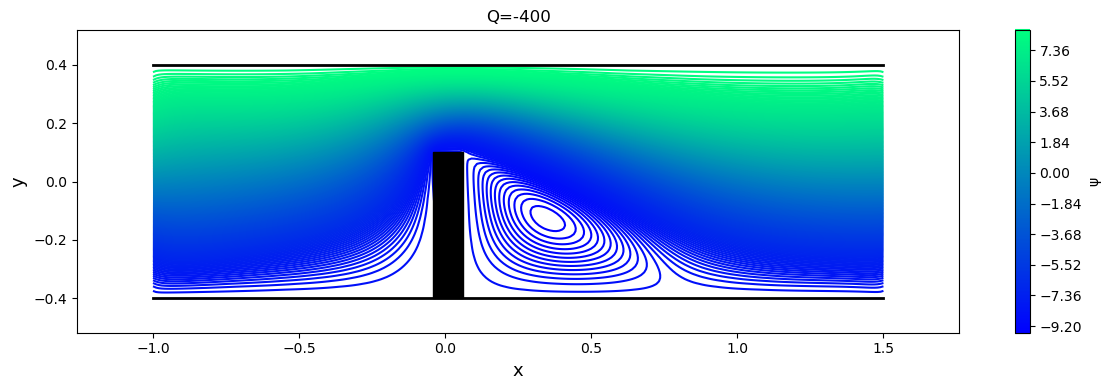

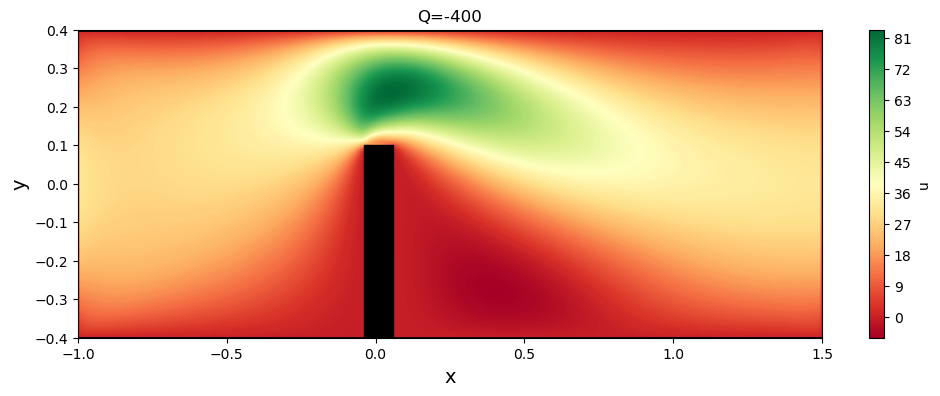

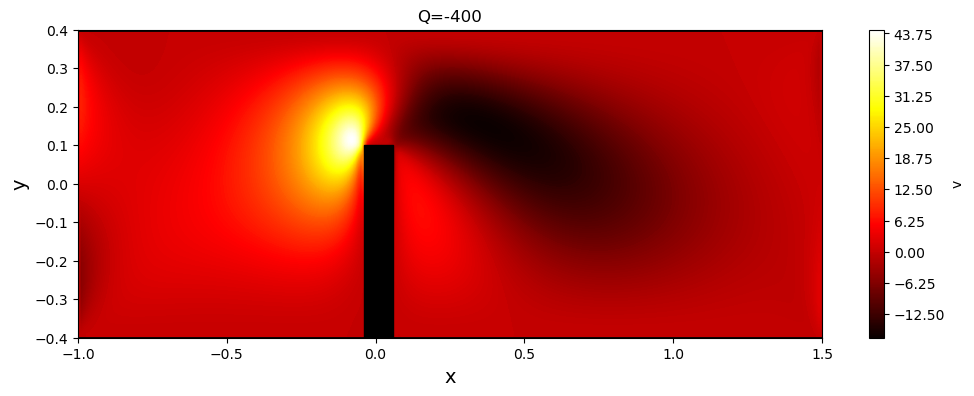

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def run_simulation(Q, max_iter=50000, tolerance=1e-7):

    dz = 0.01
    mu = 1
    rho = 1
    y1 = -0.4
    y2 = 0.4

    x_min, x_max = -100, 150
    y_min, y_max = -40, 40
    nx = int((x_max - x_min)) + 1
    ny = int((y_max - y_min)) + 1
    x = np.linspace(x_min * dz, x_max * dz, nx)
    y = np.linspace(y_min * dz, y_max * dz, ny)
    X, Y = np.meshgrid(x, y, indexing='ij')

    psi = np.zeros((nx, ny))
    zeta = np.zeros((nx, ny))

    def psi_func(y):
        return Q / (2 * mu) * (y**3 / 3 - y**2 / 2 * (y1 + y2) + y1 * y2 * y)

    def zeta_func(y):
        return Q / (2 * mu) * (2 * y - y1 - y2)

    check_i = int((0.5/0.01 + 100))
    check_j = int((0.0/0.01 + 40))

    ik = 5
    jk = 10
    i_left = nx - x_max - ik
    i_right = nx - x_max + ik
    j_top = jk - y_min
    j_bot = 0

    for it in range(max_iter):
        psi_old = psi.copy()
        zeta_old = zeta.copy()

        # góra i dół rury
        psi[:, 0] = psi_func(y1)
        psi[:, -1] = psi_func(y[-1])
        # boki rury
        psi[0, :] = psi_func(y)
        psi[-1, :] = psi_func(y)
        # boki przeszkody
        psi[i_left+1:i_right-1, j_top] = psi_func(y1)
        psi[i_left, 1:j_top] = psi_func(y1)
        psi[i_right, 1:j_top] = psi_func(y1)

        zeta[:, -1] = 2 * (psi[:, -2] - psi[:, -1]) / dz**2
        zeta[:i_left+1, 0] = 2 * (psi[:i_left+1, 1] - psi[:i_left+1, 0]) / dz**2
        zeta[i_right:, 0] = 2 * (psi[i_right:, 1] - psi[i_right:, 0]) / dz**2
        zeta[i_left, 1:j_top] = 2 * (psi[i_left-1, 1:j_top] - psi[i_left, 1:j_top]) / dz**2
        zeta[i_right, 1:j_top] = 2 * (psi[i_right+1, 1:j_top] - psi[i_right, 1:j_top]) / dz**2
        zeta[i_left+1:i_right-1, j_top] = 2 * (psi[i_left+1:i_right-1, j_top+1] - psi[i_left+1:i_right-1, j_top]) / dz**2

        # rogi przeszkody
        zeta[i_left, j_top] = 0.5 * (
            2 * (psi[i_left - 1, j_top] - psi[i_left, j_top]) / dz**2 +
            2 * (psi[i_left, j_top + 1] - psi[i_left, j_top]) / dz**2
        )
        zeta[i_right, j_top] = 0.5 * (
            2 * (psi[i_right + 1, j_top] - psi[i_right, j_top]) / dz**2 +
            2 * (psi[i_right, j_top + 1] - psi[i_right, j_top]) / dz**2
        )

        if it % 500 == 0:
            print(f"iter={it}: psi(50,0)={psi[150, 40]:.5f}, psi(60,20)={psi[160, 60]:.5f}")

        # psi relaksacja
        psi[1:-1, 1:-1] = 0.25 * (
            psi[2:, 1:-1] + psi[:-2, 1:-1] + psi[1:-1, 2:] + psi[1:-1, :-2] - zeta[1:-1, 1:-1] * dz**2
        )

        # zeta relaksacja
        dpsidy = (psi[1:-1, 2:] - psi[1:-1, :-2]) / (2*dz)
        dpsidx = (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2*dz)
        dzetadx = (zeta[2:, 1:-1] - zeta[:-2, 1:-1]) / (2*dz)
        dzetady = (zeta[1:-1, 2:] - zeta[1:-1, :-2]) / (2*dz)

        zeta[1:-1, 1:-1] = 0.25 * (
            zeta[2:, 1:-1] + zeta[:-2, 1:-1] + zeta[1:-1, 2:] + zeta[1:-1, :-2]
        ) - 0.25 * (dpsidy * dzetadx - dpsidx * dzetady) * dz**2

        # Sprawdzenie zbieżności
        if it >= 1000:
            d_psi = abs(psi[check_i, check_j] - psi_old[check_i, check_j])
            d_zeta = abs(zeta[check_i, check_j] - zeta_old[check_i, check_j])
            if max(d_psi, d_zeta) < tolerance:
                print(f"Zbieżność osiągnięta po {it} iteracjach.")
                break

    # Wizualizacja psi
    x0 = x[i_left]
    x1 = x[i_right]
    y0 = y[j_bot]
    y1 = y[j_top]

    plt.figure(figsize=(12, 4))
    plt.contour(X, Y, psi, levels=300, cmap='winter')
    plt.xlabel('x', fontsize=13)
    plt.ylabel('y', fontsize=13)
    plt.colorbar(label='ψ')
    plt.title(f"Q={Q}")
    plt.axis('equal')
    plt.plot([-1, 1.5], [-0.4, -0.4], 'black', lw=2)  # dół
    plt.plot([-1, 1.5], [0.4, 0.4], 'black', lw=2)  # góra
    plt.gca().add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, color='black', zorder=10))
    plt.tight_layout()
    plt.show()

    # Obliczenie prędkości u i v
    u = np.zeros_like(psi)
    v = np.zeros_like(psi)

    u[1:-1, 1:-1] = (psi[1:-1, 2:] - psi[1:-1, :-2]) / (2 * dz)
    v[1:-1, 1:-1] = -(psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2 * dz)

    # Wizualizacja rozkładu prędkości u i v
    plt.figure(figsize=(12, 4))
    plt.contourf(X, Y, u, levels=300, cmap='RdYlGn')
    plt.title(f"Q={Q}")
    plt.xlabel('x', fontsize=14)
    plt.ylabel('y', fontsize=14)
    plt.colorbar(label='u')
    plt.plot([-1, 1.5], [-0.4, -0.4], 'black', lw=2)  # dół
    plt.plot([-1, 1.5], [0.4, 0.4], 'black', lw=2)  # góra
    plt.gca().add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, color='black', zorder=10))
    
    plt.figure(figsize=(12, 4))
    plt.contourf(X, Y, v, levels=300, cmap='hot')
    plt.title(f"Q={Q}")
    plt.xlabel('x', fontsize=14)
    plt.ylabel('y', fontsize=14)
    plt.colorbar(label='v')
    plt.plot([-1, 1.5], [-0.4, -0.4], 'black', lw=2)  # dół
    plt.plot([-1, 1.5], [0.4, 0.4], 'black', lw=2)  # góra
    plt.gca().add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, color='black', zorder=10))
    

    #plt.tight_layout()
    plt.show()
    
# Uruchomienia dla różnych wartości Q
Q_values = [-1, -10, -100, -200, -400]
for Q in Q_values:
    run_simulation(Q)


# Animacja przepływu cząstek

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import matplotlib.cm as cm

# Parametry przepływu
Q = -400
mu = 1
rho = 1
dz = 0.01
y1 = -0.4
y2 = 0.4

x_min, x_max = -100, 150
y_min, y_max = -40, 40
nx = int((x_max - x_min)) + 1
ny = int((y_max - y_min)) + 1
x = np.linspace(x_min * dz, x_max * dz, nx)
y = np.linspace(y_min * dz, y_max * dz, ny)
X, Y = np.meshgrid(x, y, indexing='ij')

def psi_func(y):
    return Q / (2 * mu) * (y**3 / 3 - y**2 / 2 * (y1 + y2) + y1 * y2 * y)

psi = np.zeros((nx, ny))
zeta = np.zeros((nx, ny))
ik, jk = 5, 10
i_left = nx - x_max - ik
i_right = nx - x_max + ik
j_top = jk - y_min
j_bot = 0

check_i = int((0.5/dz + 100))
check_j = int((0.0/dz + 40))
max_iter = 5000
tolerance = 1e-6

for it in range(max_iter):
    psi_old = psi.copy()
    zeta_old = zeta.copy()
    psi[:, 0] = psi_func(y1)
    psi[:, -1] = psi_func(y[-1])
    psi[0, :] = psi_func(y)
    psi[-1, :] = psi_func(y)
    psi[i_left+1:i_right-1, j_top] = psi_func(y1)
    psi[i_left, 1:j_top] = psi_func(y1)
    psi[i_right, 1:j_top] = psi_func(y1)

    zeta[:, -1] = 2 * (psi[:, -2] - psi[:, -1]) / dz**2
    zeta[:i_left+1, 0] = 2 * (psi[:i_left+1, 1] - psi[:i_left+1, 0]) / dz**2
    zeta[i_right:, 0] = 2 * (psi[i_right:, 1] - psi[i_right:, 0]) / dz**2
    zeta[i_left, 1:j_top] = 2 * (psi[i_left-1, 1:j_top] - psi[i_left, 1:j_top]) / dz**2
    zeta[i_right, 1:j_top] = 2 * (psi[i_right+1, 1:j_top] - psi[i_right, 1:j_top]) / dz**2
    zeta[i_left+1:i_right-1, j_top] = 2 * (psi[i_left+1:i_right-1, j_top+1] - psi[i_left+1:i_right-1, j_top]) / dz**2

    zeta[i_left, j_top] = 0.5 * (
        2 * (psi[i_left - 1, j_top] - psi[i_left, j_top]) / dz**2 +
        2 * (psi[i_left, j_top + 1] - psi[i_left, j_top]) / dz**2
    )
    zeta[i_right, j_top] = 0.5 * (
        2 * (psi[i_right + 1, j_top] - psi[i_right, j_top]) / dz**2 +
        2 * (psi[i_right, j_top + 1] - psi[i_right, j_top]) / dz**2
    )

    psi[1:-1, 1:-1] = 0.25 * (
        psi[2:, 1:-1] + psi[:-2, 1:-1] + psi[1:-1, 2:] + psi[1:-1, :-2] - zeta[1:-1, 1:-1] * dz**2
    )

    dpsidy = (psi[1:-1, 2:] - psi[1:-1, :-2]) / (2*dz)
    dpsidx = (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2*dz)
    dzetadx = (zeta[2:, 1:-1] - zeta[:-2, 1:-1]) / (2*dz)
    dzetady = (zeta[1:-1, 2:] - zeta[1:-1, :-2]) / (2*dz)

    zeta[1:-1, 1:-1] = 0.25 * (
        zeta[2:, 1:-1] + zeta[:-2, 1:-1] + zeta[1:-1, 2:] + zeta[1:-1, :-2]
    ) - 0.25 * (dpsidy * dzetadx - dpsidx * dzetady) * dz**2

    d_psi = abs(psi[check_i, check_j] - psi_old[check_i, check_j])
    d_zeta = abs(zeta[check_i, check_j] - zeta_old[check_i, check_j])
    if max(d_psi, d_zeta) < tolerance and it > 1000:
        break

# Obliczenie prędkości
u = np.zeros_like(psi)
v = np.zeros_like(psi)
u[1:-1, 1:-1] = (psi[1:-1, 2:] - psi[1:-1, :-2]) / (2 * dz)
v[1:-1, 1:-1] = -(psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2 * dz)

# Cząsteczki
n_particles = 4000
particle_x = np.random.uniform(x[0], x[-1], n_particles)
particle_y = np.random.uniform(y[1], y[-1], n_particles)


fig, ax = plt.subplots(figsize=(8, 2), dpi=200)
scat = ax.scatter(particle_x, particle_y, s=2)

x0 = x[i_left]
x1 = x[i_right]
y0 = y[j_bot]
y1_rect = y[j_top]
rect = patches.Rectangle((x0, y0), x1 - x0, y1_rect - y0,
                         linewidth=1, edgecolor='black', facecolor='black', zorder=10)
ax.add_patch(rect)

ax.set_xlim(x[0], x[-1])
ax.set_ylim(y[0], y[-1])
ax.set_title("Animacja przepływu cząstek (kolor = prędkość)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect('equal')

def update(frame):
    global particle_x, particle_y
    i = np.searchsorted(x, particle_x)
    j = np.searchsorted(y, particle_y)
    i = np.clip(i, 1, nx - 2)
    j = np.clip(j, 1, ny - 2)
    vx = u[i, j]
    vy = v[i, j]
    speed = np.sqrt(vx**2 + vy**2)
    norm_speed = speed / np.max(speed)
    colors = cm.plasma(norm_speed)

    particle_x += vx * 0.001
    particle_y += vy * 0.001

    out_of_bounds = (particle_x < x[0]) | (particle_x > x[-1]) | (particle_y < y[0]) | (particle_y > y[-1])
    particle_x[out_of_bounds] = np.random.uniform(x[0], x[10], out_of_bounds.sum())
    particle_y[out_of_bounds] = np.random.uniform(y[1], y[-1], out_of_bounds.sum())

    scat.set_offsets(np.c_[particle_x, particle_y])
    scat.set_color(colors)
    return scat,

ani = animation.FuncAnimation(fig, update, frames=300, interval=5000, blit=True)
ani.save("przeplyw_kolory.gif", writer='pillow', fps=30)

plt.close(fig)

